# Analyse der neuen Parameter Sweep Ergebnisse

Dieses Notebook analysiert die Ergebnisse aus `all_results_summary_new2.csv` mit:
- 4 Aspect Ratios (6.88, 7.95, 9.03, 10.10)
- 5 Volumes (421.6, 455.9, 573.5, 691.2, 738.0 cm³)
- 16 Force targets (0-45 N)
- 4 Am/Rho Kombinationen

Die Force wurde bereits auf die Surface Area angepasst, daher ist `Force_Actual_N` die tatsächlich angewendete Kraft.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from pathlib import Path

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

In [2]:
# Daten laden
data_file = 'only_summary/all_results_summary_new2.csv'
df = pd.read_csv(data_file)

print(f"Anzahl Datenpunkte: {len(df)}")
print(f"\nSpalten: {list(df.columns)}")
print(f"\nErste Zeilen:")
df.head(10)

Anzahl Datenpunkte: 960

Spalten: ['Force_Target_N', 'Force_Actual_N', 'Aspect_Ratio_a_b', 'muscle_b_cm', 'muscle_a_cm', 'Volume_cm3', 'Am', 'Rho', 'Initial_Length_cm', 'Final_Length_cm', 'Elongation_cm', 'Strain', 'Completed_Date']

Erste Zeilen:


,Force_Target_N,Force_Actual_N,Aspect_Ratio_a_b,muscle_b_cm,muscle_a_cm,Volume_cm3,Am,Rho,Initial_Length_cm,Final_Length_cm,Elongation_cm,Strain,Completed_Date
0,36,2.751163,6.8800,27.124289,3.942484,421.6,550,10.493,27.124289,27.575964,4.516752e-01,0.016652,So 8. Feb 22:31:19 CET 2026
1,3,0.208143,7.9533,29.876603,3.756504,421.6,550,10.493,29.876603,29.916856,4.025308e-02,0.001347,So 8. Feb 22:31:20 CET 2026
2,15,1.146318,6.8800,27.124289,3.942484,421.6,550,10.493,27.124289,27.308963,1.846735e-01,0.006808,So 8. Feb 22:31:21 CET 2026
3,30,2.292636,6.8800,27.124289,3.942484,421.6,550,10.493,27.124289,27.498641,3.743516e-01,0.013801,So 8. Feb 22:31:27 CET 2026
4,27,2.063372,6.8800,27.124289,3.942484,421.6,550,10.493,27.124289,27.460294,3.360047e-01,0.012387,So 8. Feb 22:31:27 CET 2026
5,33,2.521899,6.8800,27.124289,3.942484,421.6,550,10.493,27.124289,27.537197,4.129076e-01,0.015222,So 8. Feb 22:31:30 CET 2026
6,0,0.000000,6.8800,27.124289,3.942484,421.6,550,10.493,27.124289,27.124289,-1.300000e-14,0.000000,So 8. Feb 22:31:32 CET 2026
7,9,0.687790,6.8800,27.124289,3.942484,421.6,550,10.493,27.124289,27.234505,1.102160e-01,0.004063,So 8. Feb 22:31:33 CET 2026
8,0,0.000000,7.9533,29.876603,3.756504,421.6,550,10.493,29.876603,29.876603,1.000000e-14,0.000000,So 8. Feb 22:31:34 CET 2026
9,45,3.438954,6.8800,27.124289,3.942484,421.6,550,10.493,27.124289,27.693554,5.692647e-01,0.020987,So 8. Feb 22:31:34 CET 2026


In [3]:
# Übersicht der Parameter
print("="*80)
print("PARAMETER OVERVIEW")
print("="*80)

print(f"\nAspect Ratios (b/a): {sorted(df['Aspect_Ratio_a_b'].unique())}")
print(f"Volumes [cm³]: {sorted(df['Volume_cm3'].unique())}")
print(f"Force Targets [N]: {sorted(df['Force_Target_N'].unique())}")
print(f"\nAm values: {sorted(df['Am'].unique())}")
print(f"Rho values: {sorted(df['Rho'].unique())}")

print(f"\nMuskel Länge b [cm]: {df['muscle_b_cm'].min():.2f} - {df['muscle_b_cm'].max():.2f}")
print(f"Muskel Querschnitt a [cm]: {df['muscle_a_cm'].min():.2f} - {df['muscle_a_cm'].max():.2f}")

print(f"\nElongation [cm]: {df['Elongation_cm'].min():.4f} - {df['Elongation_cm'].max():.4f}")
print(f"Strain: {df['Strain'].min():.6f} - {df['Strain'].max():.6f}")

PARAMETER OVERVIEW

Aspect Ratios (b/a): [np.float64(6.88), np.float64(7.9533), np.float64(9.0267), np.float64(10.1)]
Volumes [cm³]: [np.float64(421.6), np.float64(455.9), np.float64(573.5), np.float64(691.2), np.float64(738.0)]
Force Targets [N]: [np.int64(0), np.int64(3), np.int64(6), np.int64(9), np.int64(12), np.int64(15), np.int64(18), np.int64(21), np.int64(24), np.int64(27), np.int64(30), np.int64(33), np.int64(36), np.int64(39), np.int64(42), np.int64(45)]

Am values: [np.int64(450), np.int64(500), np.int64(550)]
Rho values: [np.float64(10.493), np.float64(10.534), np.float64(10.575)]

Muskel Länge b [cm]: 27.12 - 42.22
Muskel Querschnitt a [cm]: 3.47 - 4.75

Elongation [cm]: -0.0000 - 0.8862
Strain: 0.000000 - 0.020987


In [4]:
# Surface Area berechnen (für Konsistenz mit altem Notebook)
df['surface_area_cm2'] = df['muscle_a_cm'] ** 2

# Traction berechnen (Kraft pro Fläche)
df['traction_N_cm2'] = df['Force_Actual_N'] / df['surface_area_cm2']

# Für Vergleichbarkeit: Force rescaled auf minimum area
reference_area_cm2 = df['surface_area_cm2'].min()
df['force_rescaled_N'] = df['traction_N_cm2'] * reference_area_cm2

print(f"Surface Area Range: {df['surface_area_cm2'].min():.2f} - {df['surface_area_cm2'].max():.2f} cm²")
print(f"Reference Area (minimum): {reference_area_cm2:.4f} cm²")
print(f"\nTraction Range: {df['traction_N_cm2'].min():.6f} - {df['traction_N_cm2'].max():.6f} N/cm²")
print(f"Force Rescaled Range: {df['force_rescaled_N'].min():.4f} - {df['force_rescaled_N'].max():.4f} N")

Surface Area Range: 12.03 - 22.58 cm²
Reference Area (minimum): 12.0333 cm²

Traction Range: 0.000000 - 0.221252 N/cm²
Force Rescaled Range: 0.0000 - 2.6624 N


## Visualisierungen

### 1. Elongation vs. Force für verschiedene Geometrien

/var/folders/qg/82ll9gvd1pd4329hnkdpf8ch0000gn/T/ipykernel_10156/3184796678.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', len(volumes))


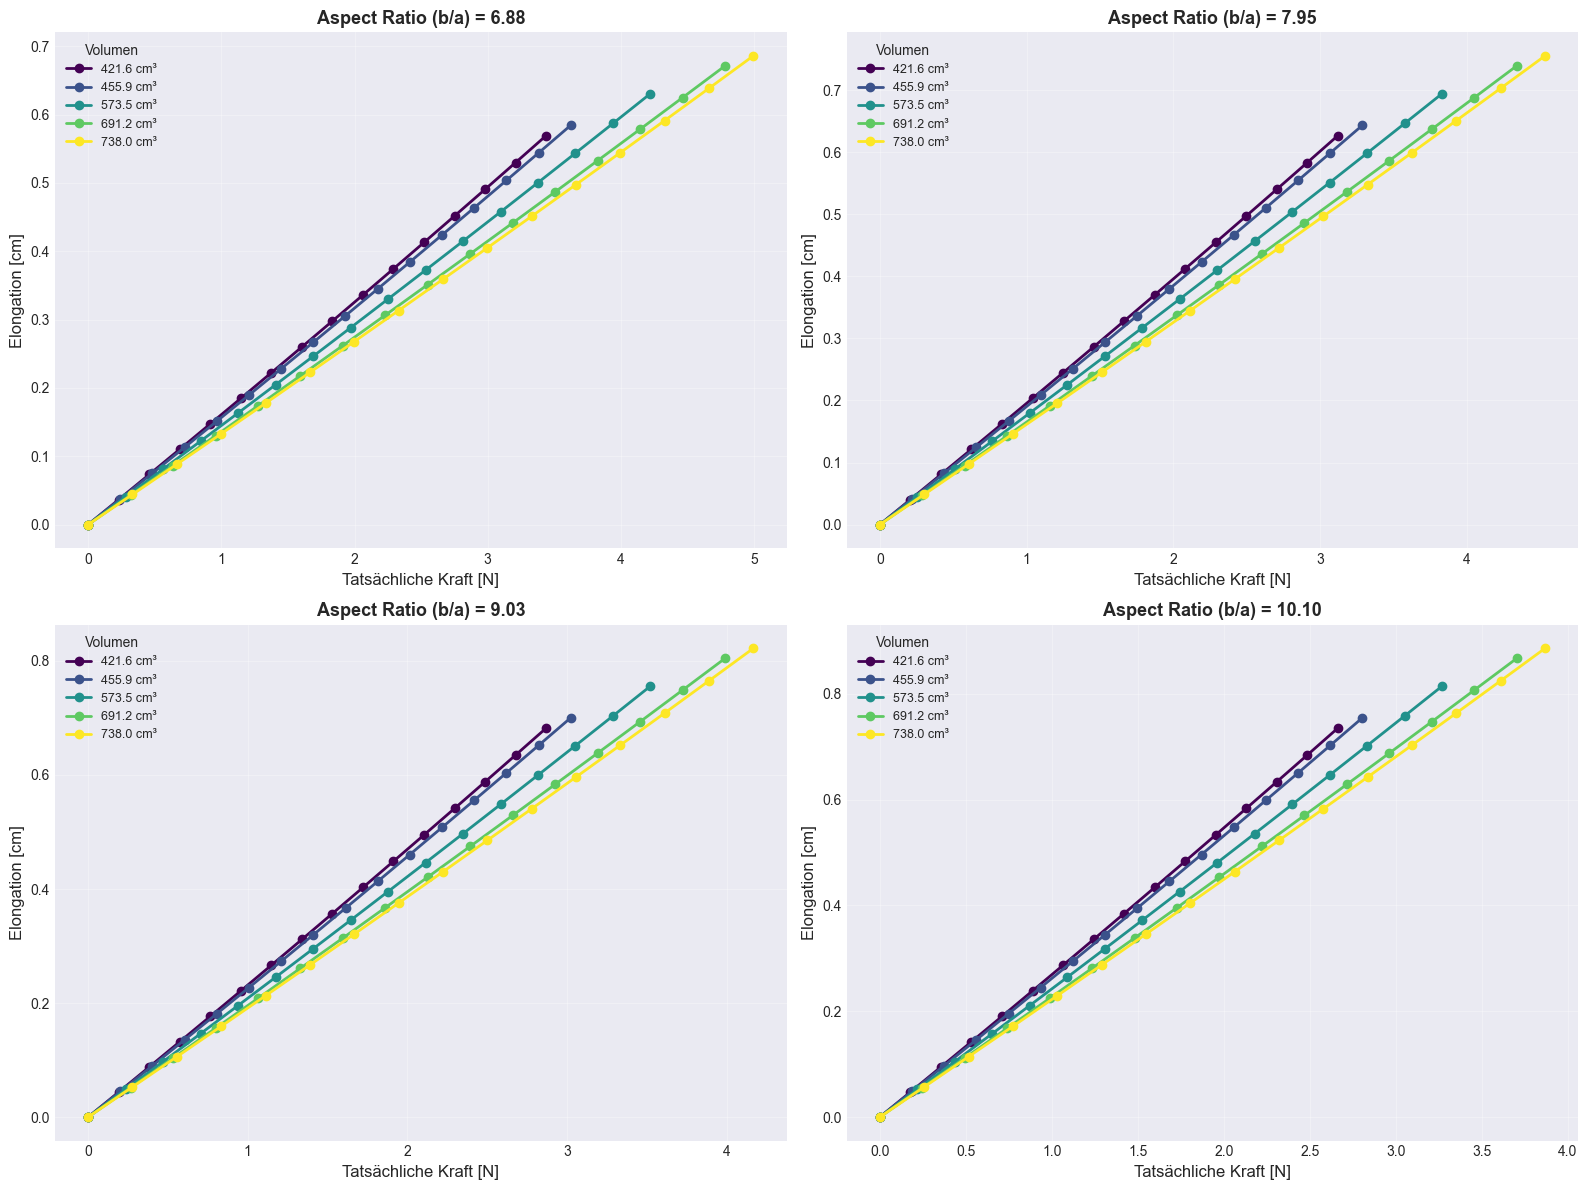

Saved: elongation_vs_force_by_aspect_ratio.png


In [5]:
# Plot 1: Elongation vs Force Actual für verschiedene Aspect Ratios
# Fixiert: Am = 550, Rho = 10.493

df_plot = df[(df['Am'] == 550) & (df['Rho'] == 10.493)]

aspect_ratios = sorted(df_plot['Aspect_Ratio_a_b'].unique())
volumes = sorted(df_plot['Volume_cm3'].unique())

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Farbzuordnung für Volumes
cmap = cm.get_cmap('viridis', len(volumes))
colors = {vol: cmap(i) for i, vol in enumerate(volumes)}

for idx, aspect_ratio in enumerate(aspect_ratios):
    ax = axes[idx]
    data_ratio = df_plot[df_plot['Aspect_Ratio_a_b'] == aspect_ratio]
    
    for volume in volumes:
        data_vol = data_ratio[data_ratio['Volume_cm3'] == volume]
        
        if len(data_vol) > 0:
            data_vol = data_vol.sort_values('Force_Actual_N')
            
            ax.plot(data_vol['Force_Actual_N'], data_vol['Elongation_cm'],
                   marker='o', linestyle='-', color=colors[volume],
                   label=f'{volume:.1f} cm³', linewidth=2, markersize=6)
    
    ax.set_xlabel('Tatsächliche Kraft [N]', fontsize=12)
    ax.set_ylabel('Elongation [cm]', fontsize=12)
    ax.set_title(f'Aspect Ratio (b/a) = {aspect_ratio:.2f}', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(title='Volumen', fontsize=9, loc='best')

plt.tight_layout()
plt.savefig('elongation_vs_force_by_aspect_ratio.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: elongation_vs_force_by_aspect_ratio.png")

/var/folders/qg/82ll9gvd1pd4329hnkdpf8ch0000gn/T/ipykernel_10156/548735094.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_ratio = cm.get_cmap('plasma', len(aspect_ratios))


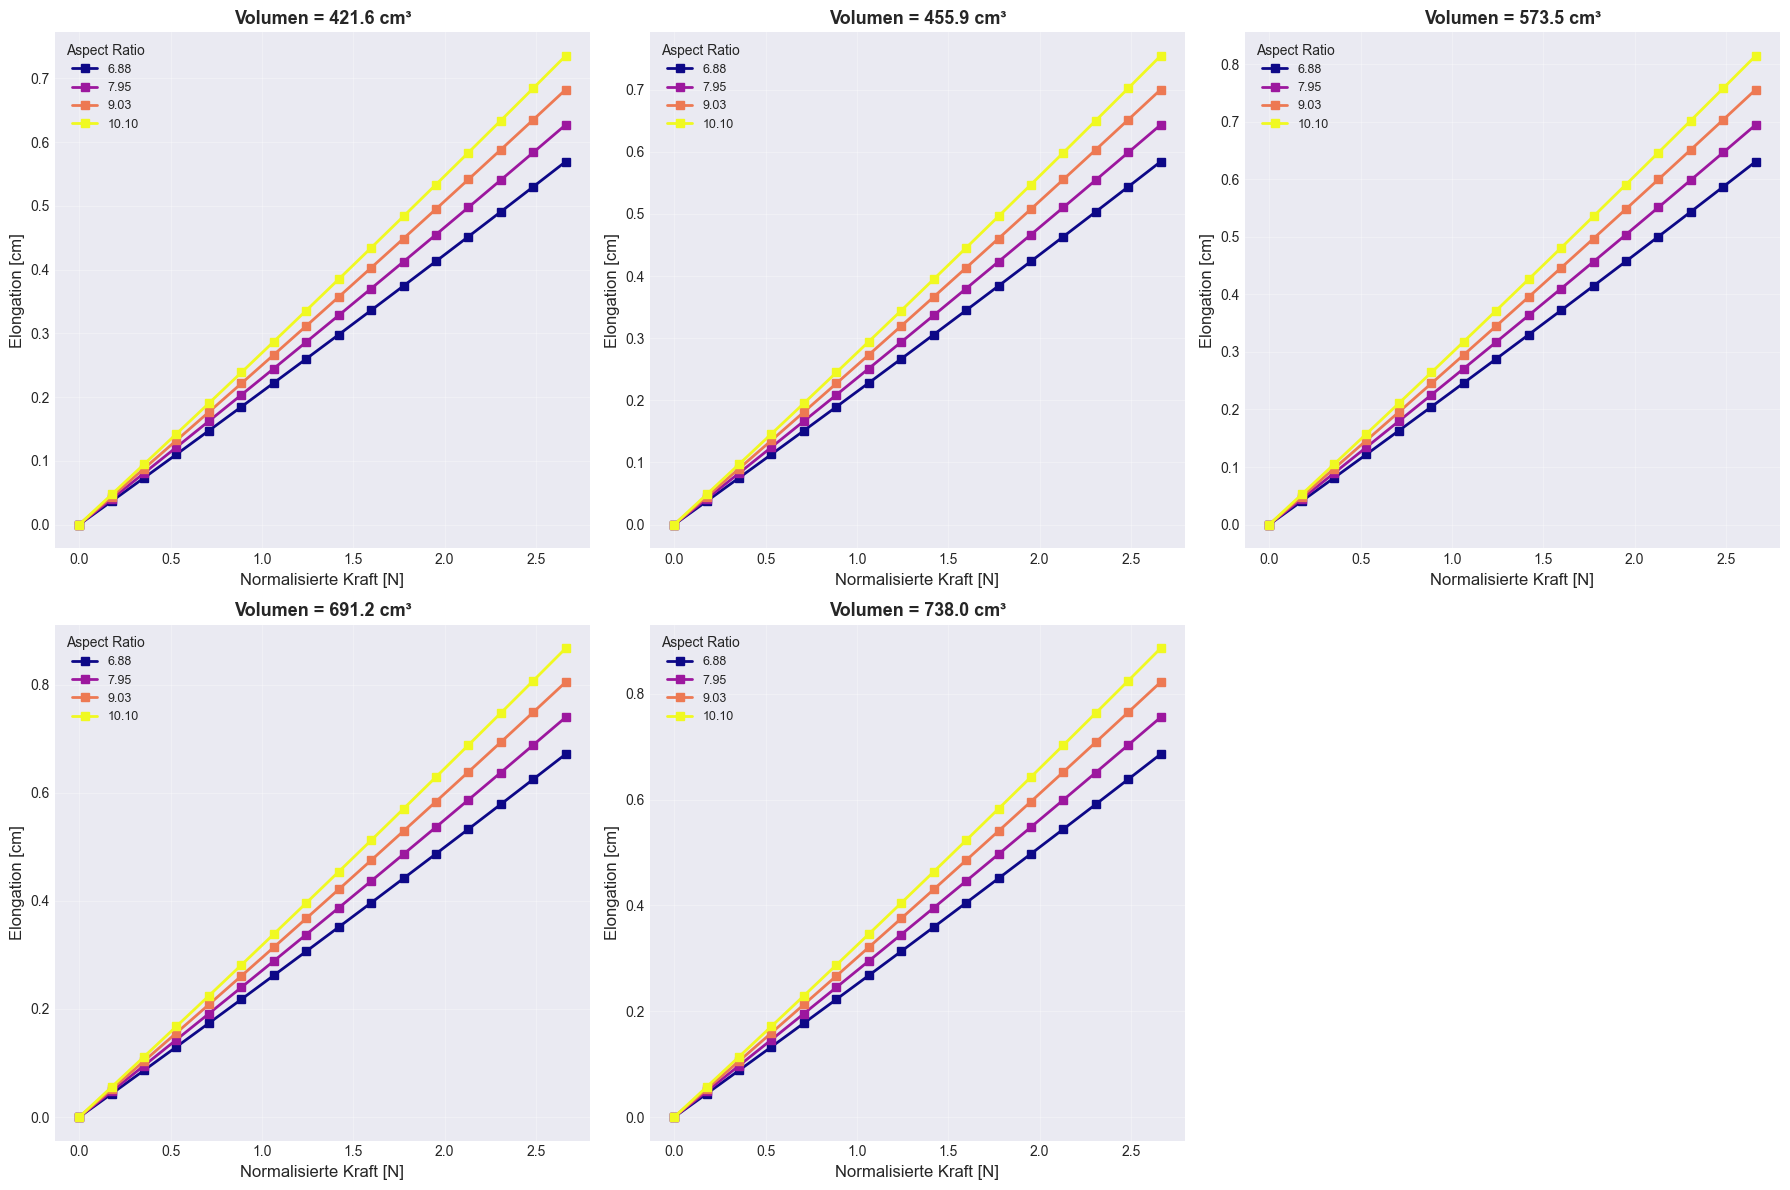

Saved: elongation_vs_rescaled_force_by_volume.png


In [6]:
# Plot 2: Elongation vs Rescaled Force für verschiedene Volumes
# Dies zeigt den Effekt bei konsistenter Traction

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Farbzuordnung für Aspect Ratios
cmap_ratio = cm.get_cmap('plasma', len(aspect_ratios))
colors_ratio = {r: cmap_ratio(i) for i, r in enumerate(aspect_ratios)}

for idx, volume in enumerate(volumes):
    ax = axes[idx]
    data_vol = df_plot[df_plot['Volume_cm3'] == volume]
    
    for aspect_ratio in aspect_ratios:
        data_ratio = data_vol[data_vol['Aspect_Ratio_a_b'] == aspect_ratio]
        
        if len(data_ratio) > 0:
            data_ratio = data_ratio.sort_values('force_rescaled_N')
            
            ax.plot(data_ratio['force_rescaled_N'], data_ratio['Elongation_cm'],
                   marker='s', linestyle='-', color=colors_ratio[aspect_ratio],
                   label=f'{aspect_ratio:.2f}', linewidth=2, markersize=6)
    
    ax.set_xlabel('Normalisierte Kraft [N]', fontsize=12)
    ax.set_ylabel('Elongation [cm]', fontsize=12)
    ax.set_title(f'Volumen = {volume:.1f} cm³', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(title='Aspect Ratio', fontsize=9, loc='best')

# Letztes Subplot ausblenden (wir haben nur 5 Volumes)
axes[5].set_visible(False)

plt.tight_layout()
plt.savefig('elongation_vs_rescaled_force_by_volume.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: elongation_vs_rescaled_force_by_volume.png")

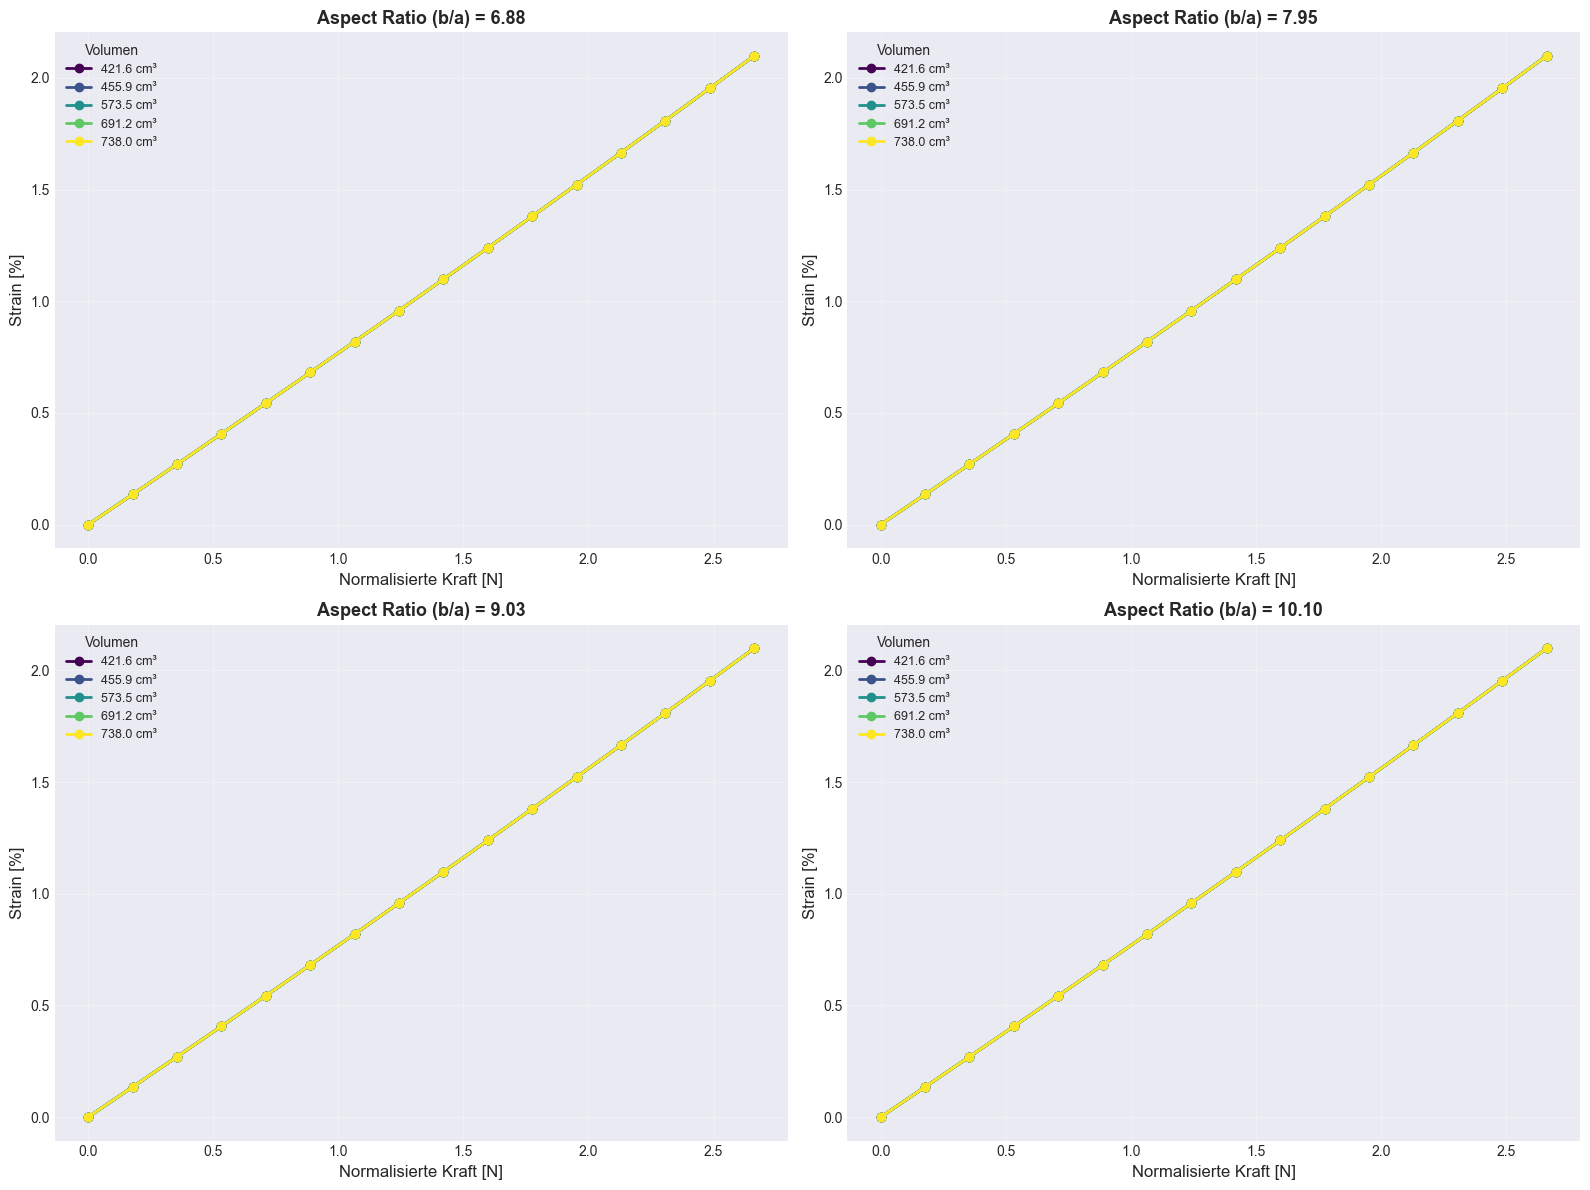

Saved: strain_vs_rescaled_force_by_aspect_ratio.png


In [7]:
# Plot 3: Strain vs Rescaled Force
# Strain normalisiert die Elongation auf die Ausgangslänge

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, aspect_ratio in enumerate(aspect_ratios):
    ax = axes[idx]
    data_ratio = df_plot[df_plot['Aspect_Ratio_a_b'] == aspect_ratio]
    
    for volume in volumes:
        data_vol = data_ratio[data_ratio['Volume_cm3'] == volume]
        
        if len(data_vol) > 0:
            data_vol = data_vol.sort_values('force_rescaled_N')
            
            ax.plot(data_vol['force_rescaled_N'], data_vol['Strain'] * 100,
                   marker='o', linestyle='-', color=colors[volume],
                   label=f'{volume:.1f} cm³', linewidth=2, markersize=6)
    
    ax.set_xlabel('Normalisierte Kraft [N]', fontsize=12)
    ax.set_ylabel('Strain [%]', fontsize=12)
    ax.set_title(f'Aspect Ratio (b/a) = {aspect_ratio:.2f}', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(title='Volumen', fontsize=9, loc='best')

plt.tight_layout()
plt.savefig('strain_vs_rescaled_force_by_aspect_ratio.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: strain_vs_rescaled_force_by_aspect_ratio.png")

### 2. Effekt der Muskel-Geometrie

/var/folders/qg/82ll9gvd1pd4329hnkdpf8ch0000gn/T/ipykernel_10156/1097723440.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_force = cm.get_cmap('coolwarm', len(selected_forces))


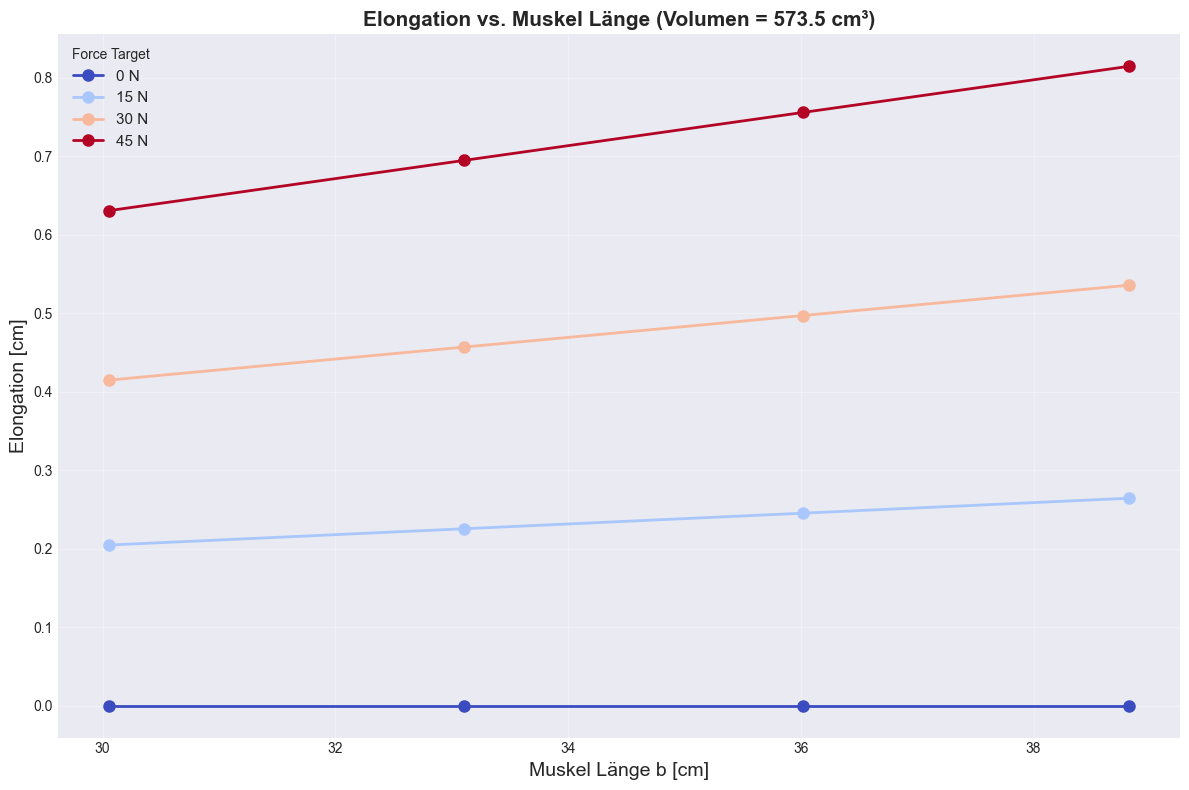

Saved: elongation_vs_muscle_length.png


In [8]:
# Plot 4: Elongation vs Muskel Länge (b) für verschiedene Kräfte
# Zeigt wie die Geometrie die Dehnung beeinflusst

# Wähle repräsentative Force Targets
selected_forces = [0, 15, 30, 45]
# Fixiere Volumen
selected_volume = 573.5  # Mittleres Volumen

data_vol = df_plot[df_plot['Volume_cm3'] == selected_volume]

fig, ax = plt.subplots(figsize=(12, 8))

# Farbzuordnung für Forces
cmap_force = cm.get_cmap('coolwarm', len(selected_forces))
colors_force = {f: cmap_force(i) for i, f in enumerate(selected_forces)}

for force in selected_forces:
    data_force = data_vol[data_vol['Force_Target_N'] == force]
    
    if len(data_force) > 0:
        data_force = data_force.sort_values('muscle_b_cm')
        
        ax.plot(data_force['muscle_b_cm'], data_force['Elongation_cm'],
               marker='o', linestyle='-', color=colors_force[force],
               label=f'{force} N', linewidth=2, markersize=8)

ax.set_xlabel('Muskel Länge b [cm]', fontsize=14)
ax.set_ylabel('Elongation [cm]', fontsize=14)
ax.set_title(f'Elongation vs. Muskel Länge (Volumen = {selected_volume} cm³)', 
             fontsize=15, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(title='Force Target', fontsize=11, loc='best')

plt.tight_layout()
plt.savefig('elongation_vs_muscle_length.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: elongation_vs_muscle_length.png")

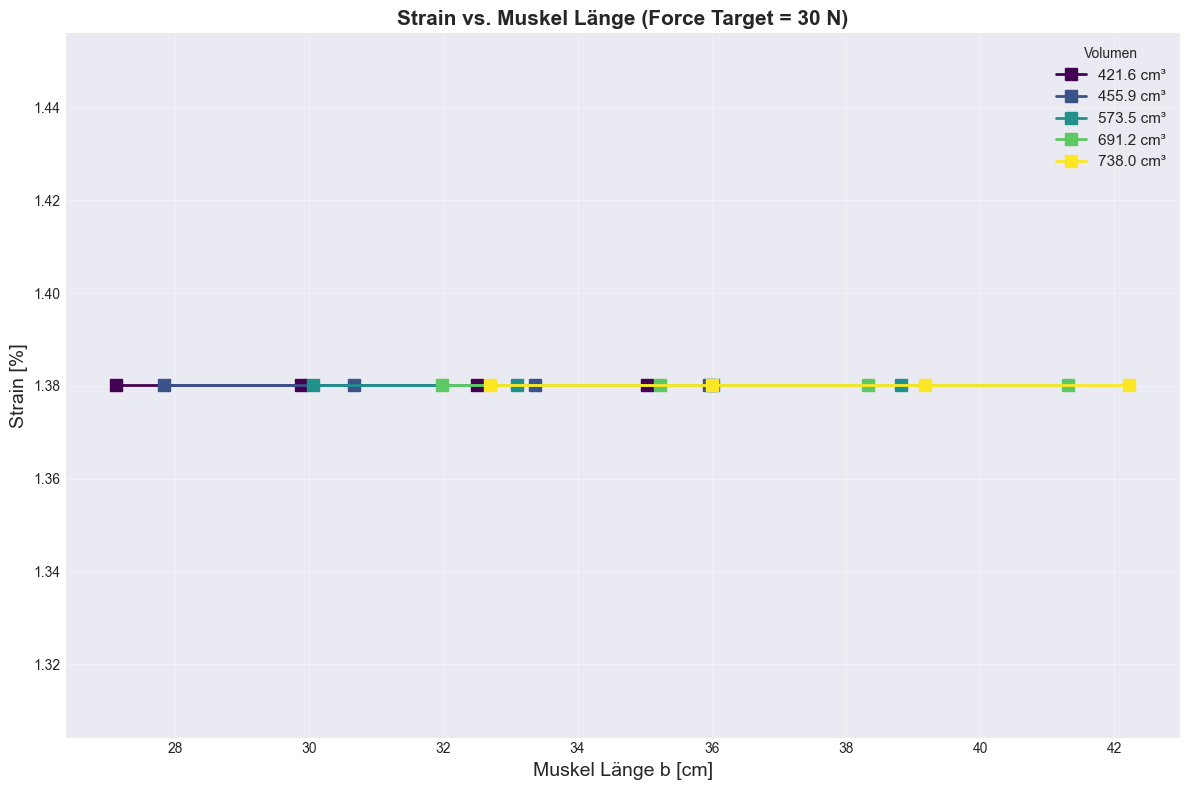

Saved: strain_vs_muscle_length.png


In [9]:
# Plot 5: Strain vs Muskel Länge für verschiedene Volumes
# Bei fixierter Kraft

selected_force = 30  # Mittlere Kraft

data_force = df_plot[df_plot['Force_Target_N'] == selected_force]

fig, ax = plt.subplots(figsize=(12, 8))

for volume in volumes:
    data_vol = data_force[data_force['Volume_cm3'] == volume]
    
    if len(data_vol) > 0:
        data_vol = data_vol.sort_values('muscle_b_cm')
        
        ax.plot(data_vol['muscle_b_cm'], data_vol['Strain'] * 100,
               marker='s', linestyle='-', color=colors[volume],
               label=f'{volume:.1f} cm³', linewidth=2, markersize=8)

ax.set_xlabel('Muskel Länge b [cm]', fontsize=14)
ax.set_ylabel('Strain [%]', fontsize=14)
ax.set_title(f'Strain vs. Muskel Länge (Force Target = {selected_force} N)', 
             fontsize=15, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(title='Volumen', fontsize=11, loc='best')

plt.tight_layout()
plt.savefig('strain_vs_muscle_length.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: strain_vs_muscle_length.png")

### 3. Vergleich verschiedener Am/Rho Kombinationen

/var/folders/qg/82ll9gvd1pd4329hnkdpf8ch0000gn/T/ipykernel_10156/4067396642.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_combo = cm.get_cmap('tab10', len(am_rho_combos))


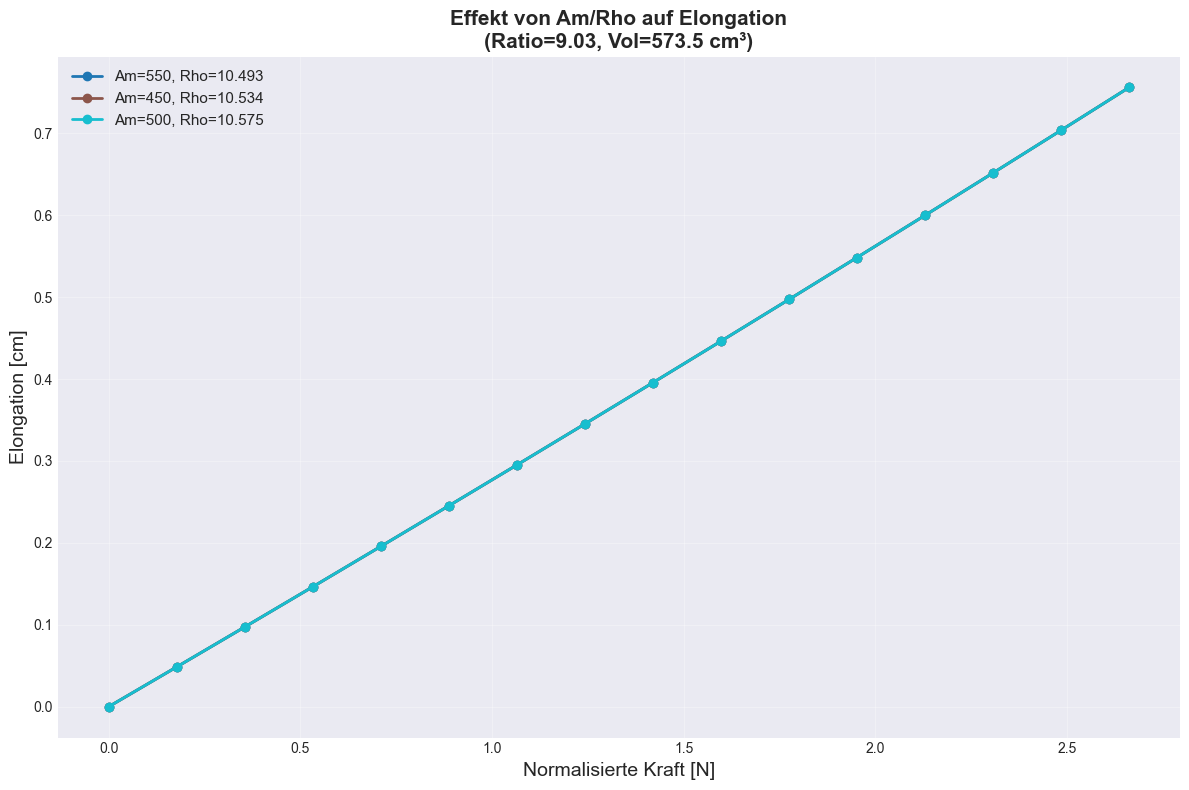

Saved: elongation_vs_force_am_rho_comparison.png


In [10]:
# Plot 6: Elongation vs Force für verschiedene Am/Rho Kombinationen
# Fixiert: Aspect Ratio = 9.0267 (mittlere), Volumen = 573.5

selected_ratio = 9.0267
selected_volume = 573.5

data_geom = df[(df['Aspect_Ratio_a_b'] == selected_ratio) & 
               (df['Volume_cm3'] == selected_volume)]

am_rho_combos = data_geom[['Am', 'Rho']].drop_duplicates().values

fig, ax = plt.subplots(figsize=(12, 8))

# Farbzuordnung für Am/Rho Kombinationen
cmap_combo = cm.get_cmap('tab10', len(am_rho_combos))

for idx, (am, rho) in enumerate(am_rho_combos):
    data_combo = data_geom[(data_geom['Am'] == am) & (data_geom['Rho'] == rho)]
    
    if len(data_combo) > 0:
        data_combo = data_combo.sort_values('force_rescaled_N')
        
        ax.plot(data_combo['force_rescaled_N'], data_combo['Elongation_cm'],
               marker='o', linestyle='-', color=cmap_combo(idx),
               label=f'Am={am:.0f}, Rho={rho:.3f}', linewidth=2, markersize=6)

ax.set_xlabel('Normalisierte Kraft [N]', fontsize=14)
ax.set_ylabel('Elongation [cm]', fontsize=14)
ax.set_title(f'Effekt von Am/Rho auf Elongation\n(Ratio={selected_ratio:.2f}, Vol={selected_volume} cm³)', 
             fontsize=15, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='best')

plt.tight_layout()
plt.savefig('elongation_vs_force_am_rho_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: elongation_vs_force_am_rho_comparison.png")

### 4. Zusammenfassende Statistik

In [11]:
# Statistische Zusammenfassung
print("="*80)
print("STATISTISCHE ZUSAMMENFASSUNG")
print("="*80)

print("\nElongation Statistik [cm]:")
print(df['Elongation_cm'].describe())

print("\nStrain Statistik [%]:")
print((df['Strain'] * 100).describe())

# Gruppierung nach Aspect Ratio
print("\n" + "="*80)
print("MITTELWERTE nach Aspect Ratio")
print("="*80)
summary = df.groupby('Aspect_Ratio_a_b').agg({
    'Elongation_cm': ['mean', 'std'],
    'Strain': ['mean', 'std'],
    'muscle_b_cm': 'first'
}).round(4)
print(summary)

# Gruppierung nach Volumen
print("\n" + "="*80)
print("MITTELWERTE nach Volumen")
print("="*80)
summary = df.groupby('Volume_cm3').agg({
    'Elongation_cm': ['mean', 'std'],
    'Strain': ['mean', 'std']
}).round(4)
print(summary)

STATISTISCHE ZUSAMMENFASSUNG

Elongation Statistik [cm]:
count    9.600000e+02
mean     3.560885e-01
std      2.273941e-01
min     -2.000000e-14
25%      1.615208e-01
50%      3.451096e-01
75%      5.408568e-01
max      8.861794e-01
Name: Elongation_cm, dtype: float64

Strain Statistik [%]:
count    960.000000
mean       1.036106
std        0.645261
min        0.000000
25%        0.508975
50%        1.028150
75%        1.557950
max        2.098700
Name: Strain, dtype: float64

MITTELWERTE nach Aspect Ratio
                 Elongation_cm          Strain         muscle_b_cm
                          mean     std    mean     std       first
Aspect_Ratio_a_b                                                  
6.8800                  0.3102  0.1953  0.0104  0.0065     27.1243
7.9533                  0.3417  0.2152  0.0104  0.0065     29.8766
9.0267                  0.3718  0.2341  0.0104  0.0065     32.5077
10.1000                 0.4007  0.2523  0.0104  0.0065     35.0359

MITTELWERTE nach V

In [12]:
# Export einer erweiterten Tabelle mit allen berechneten Werten
output_file = 'only_summary/all_results_summary_extended.csv'

df_output = df[[
    'Force_Target_N', 'Force_Actual_N', 'force_rescaled_N',
    'Aspect_Ratio_a_b', 'muscle_b_cm', 'muscle_a_cm', 
    'Volume_cm3', 'surface_area_cm2', 'traction_N_cm2',
    'Am', 'Rho',
    'Initial_Length_cm', 'Final_Length_cm', 
    'Elongation_cm', 'Strain'
]].copy()

df_output.to_csv(output_file, index=False)
print(f"\nErweiterte Ergebnisse gespeichert: {output_file}")
print(f"Anzahl Zeilen: {len(df_output)}")


Erweiterte Ergebnisse gespeichert: only_summary/all_results_summary_extended.csv
Anzahl Zeilen: 960
